In [ ]:
# Data inspection 

In [13]:
# ============================================
# ONE-CELL: rollout viz with *clear* legends
#   - Xro : executed state trajectory (simulated)
#   - Xid : desired/reference trajectory (goal/plan), if present
#   - Iro : image streams for each executed step (rgb/semantic/depth)
#   - Conventions used in this plot:
#       Xro has N+1 states: index 0 = initial state, indices 1..N = executed steps
#       Iro has N images: image k corresponds to executed step k+1 in Xro
# ============================================

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, Any, Optional, Tuple, List

# -----------------------------
# Geometry helpers
# -----------------------------
def set_axes_equal_3d(ax):
    """Make 3D axes have equal scale (so a cube looks like a cube)."""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    plot_radius = 0.5 * max([x_range, y_range, z_range])
    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

def _as_numpy(x):
    return x.detach().cpu().numpy() if hasattr(x, "detach") else np.asarray(x)

def _extract_positions_any(X_np: np.ndarray) -> np.ndarray:
    """
    Return positions P:(T,3) from:
      - (D,T) where D>=3 => take rows 0:3 then transpose
      - (T,D) where D>=3 => take cols 0:3
    """
    if X_np.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape={X_np.shape}")
    if X_np.shape[0] >= 3 and X_np.shape[0] < X_np.shape[1]:
        P = X_np[:3, :].T
    else:
        if X_np.shape[1] < 3:
            raise ValueError(f"Second dim < 3, shape={X_np.shape}")
        P = X_np[:, :3]
    return P.astype(np.float32, copy=False)

def downsample_pcd(pcd, n, seed=0):
    """Random downsample point cloud to n points."""
    pcd = np.asarray(pcd)
    if pcd.shape[0] <= n:
        return pcd
    rng = np.random.default_rng(seed)
    idx = rng.choice(pcd.shape[0], size=int(n), replace=False)
    return pcd[idx]

def crop_pcd_around_traj(pcd, P, pad=1.0):
    """Crop point cloud to bbox around trajectory (+pad)."""
    mn = P.min(axis=0) - pad
    mx = P.max(axis=0) + pad
    mask = np.all((pcd >= mn) & (pcd <= mx), axis=1)
    return pcd[mask], mn, mx

# -----------------------------
# Collision / success helpers
# -----------------------------
def _extract_positions_from_Xro(Xro_np: np.ndarray) -> np.ndarray:
    """Return X:(T,3) from Xro (D,T) or (T,D)."""
    if Xro_np.ndim != 2:
        raise ValueError(f"Unexpected Xro shape={Xro_np.shape}")
    if Xro_np.shape[0] >= 3 and Xro_np.shape[0] < Xro_np.shape[1]:
        X = Xro_np[:3, :].T
    else:
        if Xro_np.shape[1] < 3:
            raise ValueError(f"Xro second dim < 3: {Xro_np.shape}")
        X = Xro_np[:, :3]
    return X.astype(np.float32, copy=False)

def compute_clearances_collisiondetector(env_pcd, P, clearance_threshold=0.30, max_t_eval=None):
    """
    P: (T,3) executed positions (typically from Xro)
    """
    from sousvide.rl.collision_detector import CollisionDetector

    det = CollisionDetector(point_cloud=env_pcd, collision_radius=clearance_threshold)

    fn = None
    for fn_name in ["compute_clearances", "compute_clearance", "get_clearances", "clearances"]:
        if hasattr(det, fn_name):
            fn = getattr(det, fn_name)
            break
    if fn is None:
        raise RuntimeError("CollisionDetector found but no clearance method among known names.")

    T = P.shape[0]
    T_eval = T if (max_t_eval is None) else min(T, int(max_t_eval))
    Psub = P[:T_eval]

    clear = fn(Psub)
    clear = np.asarray(clear).reshape(-1).astype(np.float32, copy=False)

    hits = clear < float(clearance_threshold)
    collision = bool(np.any(hits))
    first_collision_t = int(np.argmax(hits)) if collision else None
    clear_min = float(np.min(clear)) if clear.size > 0 else float("inf")
    return clear, collision, first_collision_t, clear_min

def infer_success_from_Xid(r: dict, P_exec: np.ndarray, success_tol=0.5):
    """
    If Xid exists: success = ||P_exec_end - P_goal|| < success_tol
    where P_goal = last position of Xid.
    """
    if not (isinstance(r, dict) and r.get("Xid", None) is not None):
        return None, None, None, None

    Xid_np = _as_numpy(r["Xid"])
    P_id = _extract_positions_any(Xid_np)
    goal_pt = P_id[-1].astype(np.float32, copy=False)
    goal_dist = float(np.linalg.norm(P_exec[-1] - goal_pt))
    success = bool(goal_dist < float(success_tol))
    return success, goal_pt, goal_dist, P_id

# -----------------------------
# Plot (with explicit legend/labels)
# -----------------------------
def plot_rollout_3d_labeled(
    env_pcd: np.ndarray,
    Xro_np: np.ndarray,
    r: Optional[dict] = None,
    clearance_threshold: float = 0.30,
    success_tol: float = 0.5,
    clear: Optional[np.ndarray] = None,
    crop_pad: float = 1.8,
    pcd_plot_n: int = 30000,
    traj_stride: int = 1,
    elev: int = 22,
    azim: int = -60,
    title: Optional[str] = None,
):
    """
    Clear semantics on the figure:
      - Executed trajectory = Xro (positions from Xro)
      - Start = Xro initial state (index 0)
      - End   = Xro last executed state (index N)
      - Desired/reference = Xid (if exists)
         * Xid start, Xid end(goal)
      - Collision hits = timesteps where clearance < threshold (triangles)
    """
    # Executed positions from Xro
    P_exec_full = _extract_positions_any(np.asarray(Xro_np))
    # For Xro, we usually want the whole thing (N+1 states incl initial)
    # But color/time is nicer on executed steps only; keep both:
    P0 = P_exec_full[0]      # initial
    P_exec = P_exec_full[1:] # executed steps (N,3) if initial exists

    if P_exec.shape[0] == 0:
        raise ValueError("Xro seems to contain only 1 state (no executed steps).")

    # Success & Xid
    success, goal_pt, goal_dist, P_id = infer_success_from_Xid(r or {}, P_exec_full, success_tol=success_tol)

    # Crop + downsample
    pcd_crop, mn, mx = crop_pcd_around_traj(env_pcd, P_exec_full, pad=crop_pad)
    pcd_vis = downsample_pcd(pcd_crop, pcd_plot_n, seed=0)

    fig = plt.figure(figsize=(10.5, 8.2))
    ax = fig.add_subplot(111, projection="3d")

    # Obstacles
    ax.scatter(
        pcd_vis[:, 0], pcd_vis[:, 1], pcd_vis[:, 2],
        s=1, alpha=0.08, depthshade=False, label="Env point cloud"
    )

    # Executed trajectory (color by time)
    Pp = P_exec[::traj_stride]
    T = Pp.shape[0]
    t = np.linspace(0.0, 1.0, T)
    sc = ax.scatter(
        Pp[:, 0], Pp[:, 1], Pp[:, 2],
        c=t, s=18, alpha=0.95, label="Xro executed (color=time)"
    )
    ax.plot(Pp[:, 0], Pp[:, 1], Pp[:, 2], linewidth=1.5, alpha=0.9)

    # Xro start/end markers
    ax.scatter([P0[0]], [P0[1]], [P0[2]], s=120, marker="o", label="Xro start (initial state)")
    ax.scatter([P_exec_full[-1, 0]], [P_exec_full[-1, 1]], [P_exec_full[-1, 2]],
               s=140, marker="X", label="Xro end (final state)")

    # Xid (desired/reference) if present
    if P_id is not None:
        # Plot full desired path
        ax.plot(P_id[:, 0], P_id[:, 1], P_id[:, 2],
                linestyle="--", linewidth=2.2, alpha=0.9, label="Xid desired/reference (dashed)")
        # Mark Xid start and goal
        ax.scatter([P_id[0, 0]], [P_id[0, 1]], [P_id[0, 2]],
                   s=120, marker="s", label="Xid start")
        ax.scatter([P_id[-1, 0]], [P_id[-1, 1]], [P_id[-1, 2]],
                   s=180, marker="*", label="Xid goal (end)")

    # Collision hits (if clearances provided)
    collision = None
    first_collision_t = None
    clear_min = None
    if clear is not None:
        clear = np.asarray(clear).reshape(-1)
        clear_min = float(np.min(clear)) if clear.size > 0 else None

        # IMPORTANT: clear is usually aligned with executed steps (N)
        # We'll map clear[k] to P_exec_full[k+1]
        hit_idx = np.where(clear < float(clearance_threshold))[0]
        if hit_idx.size > 0:
            collision = True
            first_collision_t = int(hit_idx[0])
            P_hit = P_exec_full[hit_idx + 1]
            ax.scatter(P_hit[:, 0], P_hit[:, 1], P_hit[:, 2],
                       s=90, marker="^", label=f"Collision hits (clear<{clearance_threshold})")
        else:
            collision = False

    # View and limits
    ax.set_xlim(mn[0], mx[0])
    ax.set_ylim(mn[1], mx[1])
    ax.set_zlim(mn[2], mx[2])
    set_axes_equal_3d(ax)
    ax.view_init(elev=elev, azim=azim)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    # Title + metrics block
    bits = []
    if collision is not None:
        bits.append(f"collision={collision}")
        if collision and first_collision_t is not None:
            bits.append(f"first_hit_step={first_collision_t} (exec index)")
    if clear_min is not None:
        bits.append(f"clear_min={clear_min:.3f}")
    if success is not None:
        bits.append(f"success={success}")
    if goal_dist is not None:
        bits.append(f"goal_dist={goal_dist:.3f}")
    subtitle = (" | ".join(bits)) if bits else ""

    rid = None
    if isinstance(r, dict):
        rid = r.get("rollout_id", None)
    ax.set_title((title or (rid or "Rollout")) + (f"\n{subtitle}" if subtitle else ""))

    cb = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.08)
    cb.set_label("normalized time along executed steps (Xro)")

    # Legend outside-ish (avoid hiding plot)
    ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.98), fontsize=9)

    plt.tight_layout()
    plt.show()
    
def _cv2_frame_count(video_path: Path) -> int:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return -1
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return n

def pick_video_for_range(mp4_paths: List[Path], end_id: int) -> Optional[Tuple[Path, int]]:
    """
    Pick the first mp4 whose frame_count > end_id (so it contains end_id inclusive).
    Returns (path, frame_count) or None.
    """
    end_id = int(end_id)
    for p in sorted(mp4_paths):
        n = _cv2_frame_count(p)
        if n > end_id:
            return p, n
    return None

def resolve_rollout_dir(cohort_path: Path, scene: str) -> Path:
    d = Path(cohort_path) / "rollout_data" / scene
    if not d.exists():
        raise FileNotFoundError(f"Missing rollout dir: {d}")
    return d

 
def load_frames_inclusive(video_path: Path, start_id: int, end_id: int) -> np.ndarray:
    """
    Load frames [start_id .. end_id] INCLUSIVE from mp4.
    Return (N,H,W,3) uint8 in RGB order.
    """
    video_path = Path(video_path)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    start_id = int(start_id)
    end_id = int(end_id)

    if start_id < 0 or end_id < start_id:
        cap.release()
        raise ValueError(f"Bad range: start_id={start_id}, end_id={end_id}")
    if start_id >= total:
        cap.release()
        raise ValueError(f"start_id={start_id} >= total_frames={total} for {video_path}")

    end_id = min(end_id, total - 1)  # inclusive clamp

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_id)
    frames = []
    cur = start_id
    while cur <= end_id:
        ok, bgr = cap.read()
        if not ok:
            break
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        frames.append(rgb)
        cur += 1

    cap.release()

    if len(frames) == 0:
        raise RuntimeError(f"Loaded 0 frames from {video_path} for [{start_id},{end_id}]")

    return np.stack(frames, axis=0).astype(np.uint8, copy=False)
def load_rollout_and_rebuild_Iro(
    workspace_path: Path,
    cohort: str,
    scene: str,
    file_id: str,
    rollout_idx: int,
    env_pcd_path: Optional[Path] = None,
    prefer_semantic: bool = True,
    video_rgb: Optional[Path] = None,
    video_semantic: Optional[Path] = None,
    video_depth: Optional[Path] = None,
    auto_pick_videos: bool = True,
    verbose: bool = True,
) -> Dict[str, Any]:
    """
    ONE CALL => returns a Max-like `raw_trajectory` + env_pcd + plot-ready X.

    What it does:
      1) load trajectories{file_id}.pt -> pick rollout_idx entry r (dict with Xro, etc.)
      2) load imgdata{file_id}.pt (or imgdata_*) -> get start_id/end_id for SAME rollout_idx
      3) rebuild Iro from mp4 videos using [start_id..end_id] inclusive
         - if auto_pick_videos=True and video_* not provided, it will pick mp4s whose frame_count > end_id
      4) return dict with:
         - raw_trajectory: {"Tro","Xro","Uro","Iro","obj"(if present)}
         - rollout_entry: r
         - X: (T,3) extracted from Xro
         - img_entry: dict(start_id,end_id,rollout_id)
         - videos: chosen mp4 paths
         - env_pcd (optional) if env_pcd_path provided
    """
    workspace_path = Path(workspace_path)
    cohort_path = workspace_path / "cohorts" / cohort
    if not cohort_path.exists():
        raise FileNotFoundError(f"Missing cohort: {cohort_path}")

    rollout_dir = resolve_rollout_dir(cohort_path, scene)

    # --- 1) trajectories
    traj_path = rollout_dir / f"trajectories{file_id}.pt"
    if not traj_path.exists():
        raise FileNotFoundError(f"Missing trajectories file: {traj_path}")

    obj = torch.load(traj_path, map_location="cpu")
    data_list = obj.get("data", None)
    if not isinstance(data_list, list):
        raise KeyError(f"{traj_path} does not contain list at key 'data'. keys={list(obj.keys())}")

    if not (0 <= int(rollout_idx) < len(data_list)):
        raise IndexError(f"rollout_idx={rollout_idx} out of range [0,{len(data_list)-1}]")

    r = data_list[int(rollout_idx)]
    if not isinstance(r, dict):
        raise TypeError(f"Expected rollout dict at data[{rollout_idx}], got {type(r)}")

    # Extract Xro
    if r.get("Xro", None) is None:
        raise KeyError(f"Rollout missing Xro. keys={list(r.keys())}")
    Xro_np = r["Xro"].detach().cpu().numpy() if hasattr(r["Xro"], "detach") else np.asarray(r["Xro"])
    X = _extract_positions_from_Xro(Xro_np)

    # --- 2) imgdata entry (start/end)
    # Common names: imgdata{file_id}.pt, or something similar.
    img_candidates = [
        rollout_dir / f"imgdata{file_id}.pt",
        rollout_dir / f"img_data{file_id}.pt",
        rollout_dir / f"images{file_id}.pt",
    ]
    img_path = None
    for p in img_candidates:
        if p.exists():
            img_path = p
            break
    if img_path is None:
        # fallback: search any imgdata*.pt that ends with file_id
        matches = sorted(rollout_dir.glob("imgdata*.pt"))
        for p in matches:
            if p.stem.endswith(str(file_id)):
                img_path = p
                break
    if img_path is None:
        raise FileNotFoundError(f"Could not find imgdata file for file_id={file_id} under {rollout_dir}")

    imgd = torch.load(img_path, map_location="cpu")
    img_list = imgd.get("data", None)
    if not isinstance(img_list, list):
        raise KeyError(f"{img_path} does not contain list at key 'data'. keys={list(imgd.keys())}")
    if not (0 <= int(rollout_idx) < len(img_list)):
        raise IndexError(f"imgdata rollout_idx={rollout_idx} out of range [0,{len(img_list)-1}]")

    img_entry = img_list[int(rollout_idx)]
    if not isinstance(img_entry, dict):
        raise TypeError(f"Expected img_entry dict at imgd['data'][{rollout_idx}], got {type(img_entry)}")

    if not all(k in img_entry for k in ["start_id", "end_id"]):
        raise KeyError(f"img_entry missing start_id/end_id. keys={list(img_entry.keys())}")

    start_id = int(img_entry["start_id"])
    end_id = int(img_entry["end_id"])  # inclusive (per rollout_generator logic)

    # --- 3) videos
    chosen = {"rgb": None, "semantic": None, "depth": None}
    if auto_pick_videos:
        if video_rgb is None:
            pick = pick_video_for_range(list(rollout_dir.glob("video_rgb*.mp4")), end_id=end_id)
            chosen["rgb"] = pick[0] if pick else None
        else:
            chosen["rgb"] = Path(video_rgb)

        if video_semantic is None:
            pick = pick_video_for_range(list(rollout_dir.glob("video_semantic*.mp4")), end_id=end_id)
            chosen["semantic"] = pick[0] if pick else None
        else:
            chosen["semantic"] = Path(video_semantic)

        if video_depth is None:
            pick = pick_video_for_range(list(rollout_dir.glob("video_depth*.mp4")), end_id=end_id)
            chosen["depth"] = pick[0] if pick else None
        else:
            chosen["depth"] = Path(video_depth)
    else:
        chosen["rgb"] = Path(video_rgb) if video_rgb is not None else None
        chosen["semantic"] = Path(video_semantic) if video_semantic is not None else None
        chosen["depth"] = Path(video_depth) if video_depth is not None else None

    # --- 4) build Iro (Max-compatible: dict of (N,H,W,3) uint8)
    Iro: Dict[str, np.ndarray] = {}
    if chosen["rgb"] is not None and chosen["rgb"].exists():
        Iro["rgb"] = load_frames_inclusive(chosen["rgb"], start_id, end_id)

    if prefer_semantic and chosen["semantic"] is not None and chosen["semantic"].exists():
        Iro["semantic"] = load_frames_inclusive(chosen["semantic"], start_id, end_id)

    if chosen["depth"] is not None and chosen["depth"].exists():
        Iro["depth"] = load_frames_inclusive(chosen["depth"], start_id, end_id)

    if len(Iro) == 0:
        raise RuntimeError(
            f"Could not rebuild Iro: no videos found/usable. "
            f"chosen={chosen}, rollout_dir={rollout_dir}"
        )

    # Choose N from images (Max style)
    # Prefer semantic if present (often used by vision pipeline); otherwise rgb; otherwise depth.
    if "semantic" in Iro:
        N = Iro["semantic"].shape[0]
        img_key = "semantic"
    elif "rgb" in Iro:
        N = Iro["rgb"].shape[0]
        img_key = "rgb"
    else:
        N = Iro["depth"].shape[0]
        img_key = "depth"

    # Validate Xro length: should be N+1 (initial + N steps)
    # Xro_np could be (nx, N+1) or (N+1, nx) depending on writer; we only enforce one matches.
    Xro_shape = Xro_np.shape
    if (Xro_shape[0] >= 10 and Xro_shape[1] == N + 1):
        pass
    elif (Xro_shape[1] >= 10 and Xro_shape[0] == N + 1):
        pass
    else:
        raise ValueError(
            f"Xro shape mismatch vs images: Xro={Xro_shape}, images[{img_key}]={Iro[img_key].shape}. "
            f"Expected one dim == N+1={N+1}."
        )

    # Tro / Uro / obj (if present)
    # If your rollouts store these keys, keep them; if not, leave None.
    Tro = r.get("Tro", None)
    Uro = r.get("Uro", None)
    objv = r.get("obj", None)

    # If not stored, attempt to get from top-level container (sometimes different)
    if Tro is None and "Tro" in r:
        Tro = r["Tro"]
    if Uro is None and "Uro" in r:
        Uro = r["Uro"]

    raw_trajectory = {
        "Xro": Xro_np,
        "Iro": Iro,
    }
    if Tro is not None:
        raw_trajectory["Tro"] = Tro.detach().cpu().numpy() if hasattr(Tro, "detach") else np.asarray(Tro)
    if Uro is not None:
        raw_trajectory["Uro"] = Uro.detach().cpu().numpy() if hasattr(Uro, "detach") else np.asarray(Uro)
    if objv is not None:
        raw_trajectory["obj"] = objv.detach().cpu().numpy() if hasattr(objv, "detach") else np.asarray(objv)

    # Optional env_pcd
    env_pcd = None
    if env_pcd_path is not None:
        env_pcd_path = Path(env_pcd_path)
        if not env_pcd_path.exists():
            raise FileNotFoundError(f"Missing env_pcd_path: {env_pcd_path}")
        env_pcd = np.load(env_pcd_path)
        if env_pcd.ndim == 2 and env_pcd.shape[0] == 3 and env_pcd.shape[1] != 3:
            env_pcd = env_pcd.T
        env_pcd = np.asarray(env_pcd, dtype=np.float32)

    if verbose:
        rid = r.get("rollout_id", img_entry.get("rollout_id", f"idx_{rollout_idx}"))
        print(f"[OK] trajectories={traj_path.name} | imgdata={img_path.name} | rollout_idx={rollout_idx} | rollout_id={rid}")
        print(f"     img_entry: start_id={start_id}, end_id={end_id} (inclusive)")
        for k,v in chosen.items():
            print(f"     video_{k}: {str(v) if v is not None else None}")
        for k,v in Iro.items():
            print(f"     Iro['{k}'] shape={v.shape} dtype={v.dtype}")
        print(f"     Xro shape={Xro_np.shape} | X (positions)={X.shape}")

    return {
        "raw_trajectory": raw_trajectory,
        "rollout_entry": r,
        "img_entry": img_entry,
        "videos": chosen,
        "X": X,
        "env_pcd": env_pcd,
        "paths": {
            "traj_path": traj_path,
            "img_path": img_path,
            "rollout_dir": rollout_dir,
            "cohort_path": cohort_path,
        },
    }
# -----------------------------
# Minimal wrapper: compute clearances + plot with labels
# -----------------------------
def quick_plot_rollout_with_collision_labeled(
    bundle: Dict[str, Any],
    clearance_threshold: float = 0.30,
    success_tol: float = 0.5,
    crop_pad: float = 2.0,
    pcd_plot_n: int = 25000,
    traj_stride: int = 1,
    elev: int = 20,
    azim: int = -65,
    title: Optional[str] = None,
    max_t_eval: Optional[int] = None,
):
    env_pcd = bundle.get("env_pcd", None)
    if env_pcd is None:
        raise ValueError("bundle.env_pcd is None. Pass env_pcd_path to loader.")

    r = bundle["rollout_entry"]
    raw = bundle["raw_trajectory"]
    Xro_np = raw["Xro"]

    # Compute clearances on executed positions (Xro)
    P_exec_full = _extract_positions_any(np.asarray(Xro_np))
    P_exec = P_exec_full[1:]  # executed steps
    clear, collision, first_t, clear_min = compute_clearances_collisiondetector(
        env_pcd, P_exec, clearance_threshold=clearance_threshold, max_t_eval=max_t_eval
    )
    print(f"[CollisionDetector] clear_min={clear_min:.4f} | collision={collision} | first_hit_step={first_t} (exec index)")

    plot_rollout_3d_labeled(
        env_pcd=env_pcd,
        Xro_np=Xro_np,
        r=r,
        clearance_threshold=clearance_threshold,
        success_tol=success_tol,
        clear=clear,
        crop_pad=crop_pad,
        pcd_plot_n=pcd_plot_n,
        traj_stride=traj_stride,
        elev=elev,
        azim=azim,
        title=title,
    )





[OK] trajectories=trajectories00001.pt | imgdata=imgdata00001.pt | rollout_idx=5 | rollout_id=00005
     img_entry: start_id=200, end_id=239 (inclusive)
     video_rgb: /home/erwinpi/data/SINGER/cohorts/ssv_flightroom_rltraining/rollout_data/flightroom_ssv_exp/video_rgb00000.mp4
     video_semantic: /home/erwinpi/data/SINGER/cohorts/ssv_flightroom_rltraining/rollout_data/flightroom_ssv_exp/video_semantic00000.mp4
     video_depth: /home/erwinpi/data/SINGER/cohorts/ssv_flightroom_rltraining/rollout_data/flightroom_ssv_exp/video_depth00000.mp4
     Iro['rgb'] shape=(40, 360, 640, 3) dtype=uint8
     Iro['semantic'] shape=(40, 360, 640, 3) dtype=uint8
     Iro['depth'] shape=(40, 360, 640, 3) dtype=uint8
     Xro shape=(10, 41) | X (positions)=(41, 3)
[CollisionDetector] clear_min=0.4295 | collision=False | first_hit_step=None (exec index)


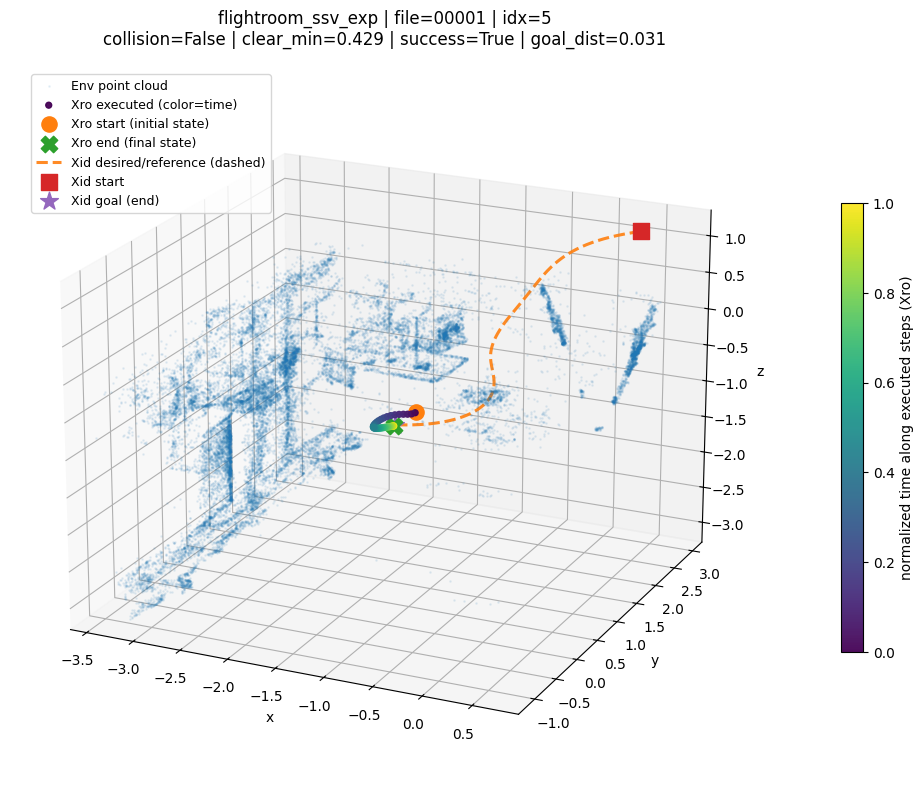

In [14]:
from pathlib import Path

# -----------------------------
# EXAMPLE USAGE (edit these)
# -----------------------------
WORKSPACE_PATH = Path("/home/erwinpi/data/SINGER")
COHORT = "ssv_flightroom_rltraining"
SCENE = "flightroom_ssv_exp"
FILE_ID = "00001"          # matches trajectories00001.pt / imgdata00001.pt (etc.)
ROLLOUT_IDX = 5            # index inside the 'data' list
ENV_PCD_PATH = Path(
    "/home/erwinpi/data/FiGS-Standalone/3dgs/workspace/outputs/flightroom_ssv_exp/gemsplat/2026-02-03_115017/pcd_cache/flightroom_ssv_exp_env_pcd.npy"
)

# 1) Load rollout + rebuild Iro from mp4 (using start_id/end_id in imgdata)
bundle = load_rollout_and_rebuild_Iro(
    workspace_path=WORKSPACE_PATH,
    cohort=COHORT,
    scene=SCENE,
    file_id=FILE_ID,
    rollout_idx=ROLLOUT_IDX,
    env_pcd_path=ENV_PCD_PATH,   # required for collision + plot
    prefer_semantic=True,        # try semantic first (if available)
    auto_pick_videos=True,       # auto-pick mp4 whose frame_count > end_id
    verbose=True,
)

# 2) Plot (with clear legend: Xro start/end, Xid start/goal, collision hits)
quick_plot_rollout_with_collision_labeled(
    bundle,
    clearance_threshold=0.30,
    success_tol=0.5,
    crop_pad=2.0,
    pcd_plot_n=25000,
    traj_stride=1,
    elev=20,
    azim=-65,
    title=f"{SCENE} | file={FILE_ID} | idx={ROLLOUT_IDX}",
    # max_t_eval=300,  # optional: only evaluate first 300 steps for collision
)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================
# CONFIG
# ==========================
COHORT = "ssv_flightroom_rltraining"
SCENE  = "flightroom_ssv_exp"
ROSTER = "InstinctJester"   # optional
ROLL_FILE_ID = "00001"      # trajectories00001.pt / imgdata00001.pt / observations00001.pt
ROLLOUT_IDX = 0             # <-- change this

ROOT = Path.home() / "data" / "SINGER" / "cohorts" / COHORT

traj_path = ROOT / "rollout_data" / SCENE / f"trajectories{ROLL_FILE_ID}.pt"
img_path  = ROOT / "rollout_data" / SCENE / f"imgdata{ROLL_FILE_ID}.pt"
obs_path  = ROOT / "observation_data" / ROSTER / SCENE / f"observations{ROLL_FILE_ID}.pt"


# ==========================
# HELPERS
# ==========================
def to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def safe_get(d, key, default=None):
    return d[key] if (isinstance(d, dict) and key in d) else default

def pretty(x):
    if isinstance(x, torch.Tensor):
        return f"torch{tuple(x.shape)} dtype={x.dtype}"
    if isinstance(x, np.ndarray):
        return f"np{tuple(x.shape)} dtype={x.dtype}"
    if isinstance(x, (list, tuple)):
        return f"{type(x).__name__}[len={len(x)}]"
    if isinstance(x, dict):
        return f"dict(keys={len(x)})"
    return repr(x)

def head_keys(d, n=30):
    if isinstance(d, dict):
        ks = list(d.keys())
        return ks[:min(n, len(ks))]
    return None

def ensure_Xro_shape(Xro_np):
    # want (Dx, T+1)
    if Xro_np.ndim != 2:
        return Xro_np
    # heuristic: if more rows than cols, it might be (T+1, Dx)
    if Xro_np.shape[0] > Xro_np.shape[1]:
        return Xro_np.T
    return Xro_np

def infer_T_from_traj(Tro_np, Xro_np, Uro_np):
    # best guess:
    # Tro len = T+1
    # Xro second dim = T+1
    # Uro second dim = T
    T_candidates = []
    if Tro_np is not None:
        Tro_np = np.asarray(Tro_np).squeeze()
        if Tro_np.ndim == 1 and Tro_np.size >= 2:
            T_candidates.append(int(Tro_np.size - 1))
    if Xro_np is not None and Xro_np.ndim == 2:
        T_candidates.append(int(Xro_np.shape[1] - 1))
    if Uro_np is not None and Uro_np.ndim == 2:
        T_candidates.append(int(Uro_np.shape[1]))
    # choose the mode/most common
    if not T_candidates:
        return None, {}
    vals, counts = np.unique(T_candidates, return_counts=True)
    T = int(vals[np.argmax(counts)])
    return T, {"candidates": T_candidates, "chosen": T}

def try_extract_images_for_rollout(imgd, rollout_id, rollout_idx):
    """
    Try multiple common layouts for imgdata.
    Returns (images, info_dict)
    """
    info = {"strategy": None}

    if imgd is None:
        return None, {"strategy": "imgd is None"}

    # Case 1: dict with "data" list/dict
    if isinstance(imgd, dict) and "data" in imgd:
        d = imgd["data"]
        # data as dict keyed by rollout_id
        if isinstance(d, dict) and rollout_id in d:
            info["strategy"] = "imgd['data'][rollout_id]"
            return d[rollout_id], info
        # data as list aligned with rollout_idx
        if isinstance(d, list) and 0 <= rollout_idx < len(d):
            info["strategy"] = "imgd['data'][rollout_idx]"
            return d[rollout_idx], info

    # Case 2: dict keyed by rollout_id directly
    if isinstance(imgd, dict) and rollout_id in imgd:
        info["strategy"] = "imgd[rollout_id]"
        return imgd[rollout_id], info

    # Case 3: list aligned with rollout_idx
    if isinstance(imgd, list) and 0 <= rollout_idx < len(imgd):
        info["strategy"] = "imgd[rollout_idx]"
        return imgd[rollout_idx], info

    # Case 4: dict with known image fields
    if isinstance(imgd, dict):
        for k in ["Iro", "rgb", "semantic", "images", "frames"]:
            if k in imgd:
                info["strategy"] = f"imgd['{k}'] (global)"
                return imgd[k], info

    info["strategy"] = "no match"
    info["imgd_type"] = type(imgd).__name__
    info["imgd_head_keys"] = head_keys(imgd)
    return None, info

def normalize_images_to_numpy(images):
    """
    Convert images container into numpy array if possible.
    Supports:
      - torch tensor (N,H,W,3) or (N,3,H,W)
      - numpy array
      - list of frames (each frame array/tensor)
      - dict with 'rgb'/'semantic'
    Returns (arr_or_list, meta)
    """
    meta = {}
    if images is None:
        return None, {"kind": "None"}

    # If dict: pick rgb or semantic
    if isinstance(images, dict):
        meta["kind"] = "dict"
        for k in ["semantic", "rgb", "depth"]:
            if k in images:
                sub = images[k]
                meta["picked"] = k
                images = sub
                break

    if isinstance(images, torch.Tensor):
        arr = images.detach().cpu().numpy()
        meta["kind"] = "torch"
        meta["shape"] = arr.shape
        return arr, meta

    if isinstance(images, np.ndarray):
        meta["kind"] = "numpy"
        meta["shape"] = images.shape
        return images, meta

    if isinstance(images, list) and len(images) > 0:
        meta["kind"] = "list"
        meta["len"] = len(images)
        # try stack if frames have same shape
        frames = []
        ok = True
        shp = None
        for f in images:
            a = to_np(f)
            if shp is None:
                shp = a.shape
            if a.shape != shp:
                ok = False
                break
            frames.append(a)
        if ok:
            arr = np.stack(frames, axis=0)
            meta["stacked"] = True
            meta["shape"] = arr.shape
            return arr, meta
        meta["stacked"] = False
        meta["first_frame_shape"] = to_np(images[0]).shape
        return images, meta

    meta["kind"] = type(images).__name__
    return images, meta

def show_image_frame(img_arr, title="frame"):
    if img_arr is None:
        print("No image to show.")
        return
    a = img_arr
    # accept (H,W,3) or (3,H,W)
    if isinstance(a, torch.Tensor):
        a = a.detach().cpu().numpy()
    a = np.asarray(a)
    if a.ndim == 3 and a.shape[0] == 3 and a.shape[-1] != 3:
        a = np.transpose(a, (1,2,0))
    if a.dtype != np.float32 and a.dtype != np.float64:
        a = a.astype(np.float32)
    if a.max() > 1.5:
        a = a / 255.0
    a = np.clip(a, 0, 1)
    plt.figure()
    plt.imshow(a)
    plt.title(title)
    plt.axis("off")
    plt.show()

# ==========================
# LOAD FILES
# ==========================
print("Loading:")
print(" traj:", traj_path)
print(" img :", img_path)
print(" obs :", obs_path)

traj = torch.load(traj_path, map_location="cpu")
imgd = torch.load(img_path,  map_location="cpu") if img_path.exists() else None
obs  = torch.load(obs_path,  map_location="cpu") if obs_path.exists() else None

print("\n== TOP LEVEL TYPES ==")
print("traj:", type(traj).__name__, "keys:", head_keys(traj))
print("imgd:", type(imgd).__name__ if imgd is not None else None, "keys:", head_keys(imgd))
print("obs :", type(obs).__name__ if obs is not None else None, "keys:", head_keys(obs))

# ==========================
# TRAJ: pick rollout
# ==========================
data_list = safe_get(traj, "data")
if data_list is None:
    raise KeyError("traj does not contain key 'data'.")

print(f"\nRollouts in trajectories file: {len(data_list)}")
if not (0 <= ROLLOUT_IDX < len(data_list)):
    raise IndexError(f"ROLLOUT_IDX={ROLLOUT_IDX} out of range [0, {len(data_list)-1}]")

r = data_list[ROLLOUT_IDX]
print("\n== ROLLOUT DICT KEYS (traj) ==")
print("keys:", sorted(list(r.keys())))

Tro = safe_get(r, "Tro")
Xro = safe_get(r, "Xro")
Uro = safe_get(r, "Uro")
Xid = safe_get(r, "Xid")
obj = safe_get(r, "obj")
rollout_id = safe_get(r, "rollout_id", f"idx_{ROLLOUT_IDX}")

if Tro is None or Xro is None or Uro is None:
    raise KeyError("Missing one of Tro / Xro / Uro in rollout.")

Tro_np = to_np(Tro).squeeze()
Xro_np = ensure_Xro_shape(to_np(Xro))
Uro_np = to_np(Uro)
Xid_np = ensure_Xro_shape(to_np(Xid)) if Xid is not None else None

T, Tinfo = infer_T_from_traj(Tro_np, Xro_np, Uro_np)

print("\n== TRAJ CORE ==")
print("rollout_id:", rollout_id)
print("Tro:", pretty(Tro_np))
print("Xro:", pretty(Xro_np))
print("Uro:", pretty(Uro_np))
print("obj:", pretty(obj))
print("Xid:", pretty(Xid_np) if Xid_np is not None else None)
print("Inferred T:", T, "details:", Tinfo)

# Consistency checks
issues = []
if Tro_np.ndim == 1 and T is not None and Tro_np.size != T+1:
    issues.append(f"Tro len={Tro_np.size} not equal T+1={T+1}")
if Xro_np.ndim == 2 and T is not None and Xro_np.shape[1] != T+1:
    issues.append(f"Xro second dim={Xro_np.shape[1]} not equal T+1={T+1}")
if Uro_np.ndim == 2 and T is not None and Uro_np.shape[1] != T:
    issues.append(f"Uro second dim={Uro_np.shape[1]} not equal T={T}")

print("\n== TRAJ CONSISTENCY ==")
if issues:
    print("❌ Issues:")
    for e in issues:
        print(" -", e)
else:
    print("✅ Tro/Xro/Uro are self-consistent.")

# ==========================
# IMGDATA: extract rollout images and verify alignment
# ==========================
images_raw, img_info = try_extract_images_for_rollout(imgd, rollout_id, ROLLOUT_IDX)
images_arr, images_meta = normalize_images_to_numpy(images_raw)

print("\n== IMGDATA EXTRACTION ==")
print("strategy:", img_info)
print("images_meta:", images_meta)

N_img = None
if isinstance(images_arr, np.ndarray) and images_arr.ndim >= 3:
    N_img = images_arr.shape[0]  # (N, ...)
elif isinstance(images_arr, list):
    N_img = len(images_arr)

print("N_img:", N_img, "| expected ~T or T+1:", T, "/", (T+1 if T is not None else None))

if T is not None and N_img is not None:
    if N_img == T:
        print("✅ Images aligned with actions timesteps (N_img == T).")
    elif N_img == T + 1:
        print("⚠ Images aligned with state length (N_img == T+1). Training might expect N_img == T; check convention.")
    else:
        print("❌ Images length does not match T or T+1. This is a red flag for offline reconstruction.")
else:
    print("⚠ Could not determine N_img or T.")

# show first image if possible
if isinstance(images_arr, np.ndarray) and images_arr.ndim >= 3 and images_arr.shape[0] > 0:
    show_image_frame(images_arr[0], title="imgdata frame[0]")
elif isinstance(images_arr, list) and len(images_arr) > 0:
    show_image_frame(images_arr[0], title="imgdata frame[0] (list)")

# ==========================
# OBSERVATIONS: inspect whether they already contain network-ready inputs
# ==========================
print("\n== OBS INSPECTION ==")
if obs is None:
    print("⚠ observations file missing. You can still train with traj+img if you regenerate obs via pilot.OODA, but you need a pilot.")
else:
    obs_data = safe_get(obs, "data", obs)
    print("obs_data:", pretty(obs_data))

    # heuristics: obs_data is list of rollouts or dict keyed by rollout_id
    o_roll = None
    o_strategy = None

    if isinstance(obs_data, dict) and rollout_id in obs_data:
        o_roll = obs_data[rollout_id]
        o_strategy = "obs_data[rollout_id]"
    elif isinstance(obs_data, list) and len(obs_data) > 0:
        # If obs_data is list of rollouts, try same index
        if 0 <= ROLLOUT_IDX < len(obs_data):
            o_roll = obs_data[ROLLOUT_IDX]
            o_strategy = "obs_data[ROLLOUT_IDX]"
        else:
            o_roll = obs_data[0]
            o_strategy = "obs_data[0] (fallback)"

    print("obs strategy:", o_strategy)
    print("obs rollout type:", type(o_roll).__name__)
    if isinstance(o_roll, dict):
        print("obs rollout keys:", sorted(list(o_roll.keys())))

        Xnn = safe_get(o_roll, "Xnn")
        Ynn = safe_get(o_roll, "Ynn")
        print("Xnn:", pretty(Xnn))
        print("Ynn:", pretty(Ynn))

        # check first timestep dict keys
        if isinstance(Xnn, (list, tuple)) and len(Xnn) > 0 and isinstance(Xnn[0], dict):
            x0 = Xnn[0]
            print("Xnn[0] keys:", sorted(list(x0.keys())))

            # network-ready?
            needed = ["tx_com","obj_com","dxu_par","img_vis","tx_vis"]
            have_all = all(k in x0 for k in needed)
            if have_all:
                print("✅ observations already contain network-ready inputs (tx_com/obj_com/dxu_par/img_vis/tx_vis).")
            elif "xnn" in x0:
                print("⚠ observations contain 'xnn' (raw). You likely need pilot.model.get_commander_data(xnn, ynn) to extract network inputs.")
            else:
                print("❌ observations format unclear: missing both network-ready keys and 'xnn'.")

        # length alignment
        if T is not None and isinstance(Xnn, (list, tuple)):
            print("len(Xnn):", len(Xnn), "| expected ~T:", T)
            if len(Xnn) == T:
                print("✅ obs length matches T.")
            elif len(Xnn) == T+1:
                print("⚠ obs length matches T+1 (state length). Convention mismatch possible.")
            else:
                print("❌ obs length mismatch with T.")
    else:
        print("❌ Could not locate a rollout-like structure inside observations file.")

print("\n=== FINAL VERDICT HEURISTIC ===")
need = []
if imgd is None:
    need.append("imgdata file (images) OR Iro inside trajectories")
if obs is None:
    need.append("observations OR ability to regenerate via pilot.OODA")
if isinstance(images_arr, (type(None),)) or (N_img is None):
    need.append("extractable images for this rollout_id")

if need:
    print("⚠ Not enough to guarantee 100% offline RL fidelity yet. Missing/uncertain:")
    for s in need:
        print(" -", s)
else:
    print("✅ You likely have everything needed for offline reconstruction (traj + images + obs).")

In [ ]:
import os
import json
import numpy as np
from pathlib import Path


# --- paths ---
GSPLAT_RUN_DIR = Path("/home/erwinpi/data/FiGS-Standalone/3dgs/workspace/outputs/flightroom_ssv_exp/gemsplat/2026-02-03_115017")
OUT_DIR = GSPLAT_RUN_DIR / "pcd_cache"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- try FiGS utilities (the "Max way") ---
def export_with_figs(scene_name="flightroom_ssv_exp", rollout_name=None):
    from figs.simulator import Simulator
    import figs.scene_editing.scene_editing_utils as scdt

    sim = Simulator(scene_name, rollout_name)  # rollout_name can be None in some setups
    _, env_pcd, env_bounds, *_ = scdt.rescale_point_cloud(
        sim.gsplat, viz=False, cull=False, verbose=True
    )
    return env_pcd, env_bounds

def main():
    # If you know rollout_name, put it here; otherwise None often still works.
    rollout_name = None
    scene_name = "flightroom_ssv_exp"

    env_pcd, env_bounds = export_with_figs(scene_name=scene_name, rollout_name=rollout_name)

    env_pcd = np.asarray(env_pcd, dtype=np.float32)
    np.save(OUT_DIR / f"{scene_name}_env_pcd.npy", env_pcd)

    # bounds can be dict or array depending on implementation
    try:
        np.save(OUT_DIR / f"{scene_name}_env_bounds.npy", np.asarray(env_bounds, dtype=np.float32))
    except Exception:
        with open(OUT_DIR / f"{scene_name}_env_bounds.json", "w") as f:
            json.dump(env_bounds, f, indent=2)

    print("saved:", OUT_DIR / f"{scene_name}_env_pcd.npy", env_pcd.shape)

if __name__ == "__main__":
    main()

In [ ]:
import glob
import numpy as np
from pathlib import Path
import torch

# =============================================================================
# CONFIG
# =============================================================================
SCENE = "flightroom_ssv_exp"

# Tu peux garder ce cohort si tes trajectories*.pt sont là:
COHORT = "ssv_flightroom_rltraining"
PILOT  = "InstinctJester"   # utilisé seulement pour le layout simulation_data

# env_pcd cache (déjà généré)
GSPLAT_RUN_DIR = Path("/home/erwinpi/data/FiGS-Standalone/3dgs/workspace/outputs/flightroom_ssv_exp/gemsplat/2026-02-03_115017")
ENV_PCD_PATH = GSPLAT_RUN_DIR / "pcd_cache" / f"{SCENE}_env_pcd.npy"

# rollout files (zipped rollout layout)
ROLL_FILE_ID = None   # ex: "00001" ; None => auto pick latest available
ROLLOUT_IDX  = 0      # index inside trajectoriesXXXX.pt

# checks
CLEARANCE_THRESHOLD = 0.30
TRAJ_MARGIN = 0.5
T_SUB = 200           # timesteps for bruteforce clearance sanity

# workspace SINGER
WORKSPACE_PATH = Path("/home/erwinpi/data/SINGER")
COHORT_PATH = WORKSPACE_PATH / "cohorts" / COHORT

# =============================================================================
# Helpers
# =============================================================================
def _load_env_pcd(pcd_path: Path) -> np.ndarray:
    if not pcd_path.exists():
        raise FileNotFoundError(f"Missing env_pcd file: {pcd_path}")
    pcd = np.load(pcd_path)

    if pcd.ndim != 2:
        raise ValueError(f"env_pcd must be 2D array, got shape={pcd.shape}")
    if pcd.shape[1] == 3:
        pcdN3 = pcd
    elif pcd.shape[0] == 3:
        pcdN3 = pcd.T
    else:
        raise ValueError(f"env_pcd must have shape (N,3) or (3,N), got shape={pcd.shape}")

    pcdN3 = np.asarray(pcdN3, dtype=np.float32)
    if not np.isfinite(pcdN3).all():
        bad = np.count_nonzero(~np.isfinite(pcdN3))
        raise ValueError(f"env_pcd contains non-finite values: {bad} bad entries")
    return pcdN3

def _bbox(pcdN3: np.ndarray):
    mn = pcdN3.min(axis=0)
    mx = pcdN3.max(axis=0)
    return mn, mx

def _inside_bbox_fraction(X: np.ndarray, mn: np.ndarray, mx: np.ndarray, margin: float = 0.0) -> float:
    lo = mn - margin
    hi = mx + margin
    inside = np.all((X >= lo) & (X <= hi), axis=1)
    return float(np.mean(inside))

def _nearest_clearance_bruteforce(pcd: np.ndarray, X: np.ndarray, chunk: int = 256) -> np.ndarray:
    # O(T*N) => subset only
    T = X.shape[0]
    out = np.empty((T,), dtype=np.float32)
    for i in range(0, T, chunk):
        Xi = X[i:i+chunk]                     # (B,3)
        dif = Xi[:, None, :] - pcd[None, :, :]  # (B,N,3)
        d2 = np.sum(dif * dif, axis=-1)       # (B,N)
        out[i:i+chunk] = np.sqrt(np.min(d2, axis=1)).astype(np.float32)
        del dif, d2
    return out

def _pick_latest_roll_file_id(rollout_scene_dir: Path):
    files = sorted(glob.glob(str(rollout_scene_dir / "trajectories*.pt")))
    if not files:
        return None
    # take highest numeric suffix if possible
    def _suffix_num(p):
        stem = Path(p).stem  # trajectories00001
        s = stem.replace("trajectories", "")
        try:
            return int(s)
        except:
            return -1
    files = sorted(files, key=_suffix_num)
    latest = Path(files[-1]).stem.replace("trajectories", "")
    return latest  # e.g. "00001"

def _load_rollout_from_rollout_data(cohort_path: Path, scene: str, file_id: str, rollout_idx: int):
    """
    Loads one rollout dict r from:
      cohort/rollout_data/<scene>/trajectories<file_id>.pt
    Expected structure: dict with key "data" -> list of rollouts (dicts).
    """
    traj_path = cohort_path / "rollout_data" / scene / f"trajectories{file_id}.pt"
    if not traj_path.exists():
        raise FileNotFoundError(f"Missing trajectories file: {traj_path}")

    traj = torch.load(traj_path, map_location="cpu")
    data_list = traj.get("data", None)
    if data_list is None or not isinstance(data_list, list):
        raise KeyError(f"{traj_path} does not contain a list at key 'data'.")

    if not (0 <= rollout_idx < len(data_list)):
        raise IndexError(f"ROLLOUT_IDX={rollout_idx} out of range [0, {len(data_list)-1}]")

    r = data_list[rollout_idx]
    if not isinstance(r, dict):
        raise TypeError(f"Expected rollout to be dict, got {type(r)}")

    # Extract Xro
    Xro = r.get("Xro", None)
    if Xro is None:
        raise KeyError(f"Rollout missing 'Xro'. keys={list(r.keys())}")

    Xro_np = Xro.detach().cpu().numpy() if isinstance(Xro, torch.Tensor) else np.asarray(Xro)

    # Normalize Xro into positions X:(T,3)
    # Commonly Xro is (state_dim, T+1) or (T+1, state_dim)
    if Xro_np.ndim != 2:
        raise ValueError(f"Unexpected Xro shape={Xro_np.shape}")

    # Heuristic: if first dim looks like state_dim (>=3 and smaller than second dim), treat as (D,T)
    if Xro_np.shape[0] >= 3 and Xro_np.shape[0] < Xro_np.shape[1]:
        X = Xro_np[:3, :].T  # (T,3)
    else:
        # assume (T,D)
        if Xro_np.shape[1] < 3:
            raise ValueError(f"Xro second dim < 3: {Xro_np.shape}")
        X = Xro_np[:, :3]

    return r, X, traj_path

def _list_simulation_data_traj_files(cohort_path: Path, pilot_name: str):
    sim_data_dir = cohort_path / "simulation_data"
    ts_dirs = sorted(glob.glob(str(sim_data_dir / "*")))
    if not ts_dirs:
        return None, []
    latest_ts = ts_dirs[-1]
    traj_dir = Path(latest_ts) / "trajectories"
    traj_files = sorted(glob.glob(str(traj_dir / f"*_traj*_{pilot_name}.pt")))
    return latest_ts, [Path(p) for p in traj_files]

# =============================================================================
# Run checks
# =============================================================================
print("COHORT_PATH:", COHORT_PATH)
print("ENV_PCD_PATH:", ENV_PCD_PATH)

env_pcd = _load_env_pcd(ENV_PCD_PATH)
mn, mx = _bbox(env_pcd)
print(f"\n[ENV_PCD] shape={env_pcd.shape} dtype={env_pcd.dtype}")
print("bbox min:", mn)
print("bbox max:", mx)
print("bbox size:", mx - mn)

# -------------------------------------------------------------------------
# 1) Try SIMULATION_DATA first (may fail if only videos exist)
# -------------------------------------------------------------------------
latest_ts, sim_traj_files = _list_simulation_data_traj_files(COHORT_PATH, PILOT)
if sim_traj_files:
    print(f"\n[SIMULATION_DATA] Found {len(sim_traj_files)} traj files under {latest_ts}/trajectories/")
    print("Example:", sim_traj_files[0].name)
else:
    print(f"\n[SIMULATION_DATA] No *_traj*_{PILOT}.pt found (often only videos). Using rollout_data layout instead.")

# -------------------------------------------------------------------------
# 2) Load from ROLLOUT_DATA layout (your zipped rollout_data)
# -------------------------------------------------------------------------
rollout_scene_dir = COHORT_PATH / "rollout_data" / SCENE
if not rollout_scene_dir.exists():
    raise FileNotFoundError(f"Missing rollout_scene_dir: {rollout_scene_dir}")

if ROLL_FILE_ID is None:
    ROLL_FILE_ID = _pick_latest_roll_file_id(rollout_scene_dir)
    if ROLL_FILE_ID is None:
        raise FileNotFoundError(f"No trajectories*.pt in {rollout_scene_dir}")
    print(f"\n[ROLLOUT_DATA] Auto-selected ROLL_FILE_ID={ROLL_FILE_ID}")

r, X, traj_path = _load_rollout_from_rollout_data(COHORT_PATH, SCENE, ROLL_FILE_ID, ROLLOUT_IDX)

rollout_id = r.get("rollout_id", f"idx_{ROLLOUT_IDX}")
print(f"\n[ROLLOUT] file={traj_path.name}  ROLLOUT_IDX={ROLLOUT_IDX} rollout_id={rollout_id}")
print("X (positions) shape:", X.shape, " (T,3)")

# -------------------------------------------------------------------------
# 3) Frame alignment sanity: how much trajectory is inside env bbox
# -------------------------------------------------------------------------
frac = _inside_bbox_fraction(X, mn, mx, margin=TRAJ_MARGIN)
print(f"\n[ALIGNMENT] inside_bbox_frac(margin={TRAJ_MARGIN}) = {frac:.3f}")
if frac < 0.5:
    print("[WARN] Trajectory mostly OUTSIDE bbox -> likely frame mismatch (env_pcd vs trajectory frame).")
else:
    print("[OK] Trajectory mostly inside bbox -> frames likely consistent.")

# -------------------------------------------------------------------------
# 4) Clearance sanity (CPU bruteforce subset)
# -------------------------------------------------------------------------
Tsub = min(T_SUB, X.shape[0])
Xsub = X[:Tsub]
clear = _nearest_clearance_bruteforce(env_pcd, Xsub, chunk=256)
hits = (clear < CLEARANCE_THRESHOLD)
print(f"\n[CLEARANCE] first {Tsub} steps:")
print(f"min={clear.min():.3f} mean={clear.mean():.3f} max={clear.max():.3f}")
print(f"collision(threshold={CLEARANCE_THRESHOLD}): {bool(hits.any())}   (#hits={hits.sum()})")

# -------------------------------------------------------------------------
# 5) Optional: compare to CollisionDetector API if available
# -------------------------------------------------------------------------
print("\n[CollisionDetector] quick API check")
try:
    from sousvide.rl.collision_detector import CollisionDetector
    det = CollisionDetector(point_cloud=env_pcd, collision_radius=CLEARANCE_THRESHOLD)

    clearance2 = None
    for fn_name in ["compute_clearances", "compute_clearance", "get_clearances", "clearances"]:
        if hasattr(det, fn_name):
            try:
                clearance2 = getattr(det, fn_name)(Xsub)
                break
            except Exception:
                pass

    if clearance2 is None:
        print("[WARN] Could not call a clearance method (API mismatch). But env_pcd is fine.")
    else:
        clearance2 = np.asarray(clearance2).reshape(-1)
        print(f"det stats: min={clearance2.min():.3f} mean={clearance2.mean():.3f} max={clearance2.max():.3f}")
        L = min(len(clearance2), len(clear))
        print(f"mean abs diff vs bruteforce subset = {np.mean(np.abs(clearance2[:L] - clear[:L])):.6f}")

except Exception as e:
    print("[WARN] CollisionDetector not available / failed:", e)

print("\nDONE.")



In [ ]:
import numpy as np
import torch
from pathlib import Path

# =========================
# CONFIG
# =========================
SCENE = "flightroom_ssv_exp"
COHORT = "ssv_flightroom_rltraining"
WORKSPACE_PATH = Path("/home/erwinpi/data/SINGER")
COHORT_PATH = WORKSPACE_PATH / "cohorts" / COHORT

GSPLAT_RUN_DIR = Path("/home/erwinpi/data/FiGS-Standalone/3dgs/workspace/outputs/flightroom_ssv_exp/gemsplat/2026-02-03_115017")
ENV_PCD_PATH = GSPLAT_RUN_DIR / "pcd_cache" / f"{SCENE}_env_pcd.npy"

# pick which rollout you want to visualize
FILE_ID = "00019"      # <-- ex "00009" (NO "trajectories" prefix)
ROLLOUT_IDX = 5        # <-- index inside trajectoriesFILE_ID.pt

CLEARANCE_THRESHOLD = 0.30
SUCCESS_TOL = 0.5

# plot settings
CROP_PAD = 2.0
PCD_PLOT_N = 25000
TRAJ_STRIDE = 1
ELEV = 20
AZIM = -65

# =========================
# LOAD env_pcd (if not already)
# =========================
if "env_pcd" not in globals():
    print("Loading env_pcd:", ENV_PCD_PATH)
    env_pcd = np.load(ENV_PCD_PATH)
    if env_pcd.ndim == 2 and env_pcd.shape[0] == 3 and env_pcd.shape[1] != 3:
        env_pcd = env_pcd.T
    env_pcd = np.asarray(env_pcd, dtype=np.float32)
    print("env_pcd:", env_pcd.shape, env_pcd.dtype)

# =========================
# LOAD rollout r + X from trajectoriesFILE_ID.pt
# =========================
traj_path = COHORT_PATH / "rollout_data" / SCENE / f"trajectories{FILE_ID}.pt"
if not traj_path.exists():
    raise FileNotFoundError(f"Missing trajectories file: {traj_path}")

obj = torch.load(traj_path, map_location="cpu")
data_list = obj.get("data", None)
if data_list is None or not isinstance(data_list, list):
    raise KeyError(f"{traj_path} does not contain list at key 'data'. keys={list(obj.keys())}")

if not (0 <= ROLLOUT_IDX < len(data_list)):
    raise IndexError(f"ROLLOUT_IDX={ROLLOUT_IDX} out of range [0, {len(data_list)-1}]")

r = data_list[ROLLOUT_IDX]
if not isinstance(r, dict):
    raise TypeError(f"Expected rollout to be dict, got {type(r)}")

if r.get("Xro", None) is None:
    raise KeyError(f"Rollout missing Xro. keys={list(r.keys())}")

# X = positions (T,3)
X = _extract_positions_from_Xro(
    r["Xro"].detach().cpu().numpy() if hasattr(r["Xro"], "detach") else np.asarray(r["Xro"])
)

rollout_id = r.get("rollout_id", f"idx_{ROLLOUT_IDX}")
print(f"Loaded: {traj_path.name} idx={ROLLOUT_IDX} rollout_id={rollout_id} | X={X.shape}")

# =========================
# 1) clearances (CollisionDetector) on full trajectory
# =========================
clear, collision, first_t, clear_min = compute_clearances_collisiondetector(
    env_pcd, X,
    clearance_threshold=CLEARANCE_THRESHOLD,
    max_t_eval=None
)

print(f"CollisionDetector: clear_min={clear_min:.4f} | collision={collision} | first_collision_t={first_t}")

# =========================
# 2) nice plot
# =========================
plot_rollout_3d_pretty(
    env_pcd, X, r=r,
    clearance_threshold=CLEARANCE_THRESHOLD,
    success_tol=SUCCESS_TOL,
    clear=clear,
    collision=collision,
    first_collision_t=first_t,
    crop_pad=CROP_PAD,
    pcd_plot_n=PCD_PLOT_N,
    traj_stride=TRAJ_STRIDE,
    elev=ELEV,
    azim=AZIM,
    title=f"{traj_path.name} idx={ROLLOUT_IDX} rollout_id={rollout_id}"
)